# MediaPipe Pose Detection on Gym Videos

This notebook demonstrates how to use MediaPipe's Pose Landmarker to detect human pose landmarks in video files, particularly gym training videos. We'll load a video, detect poses, visualize the landmarks, and save the results.

## Section 1: Import Required Libraries

Import necessary libraries including OpenCV, MediaPipe, NumPy, and Matplotlib for video processing and visualization.

In [56]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

print("✓ Bibliotecas importadas com sucesso!")
print(f"MediaPipe versão: {mp.__version__}")
print(f"OpenCV versão: {cv2.__version__}")

✓ Bibliotecas importadas com sucesso!
MediaPipe versão: 0.10.33
OpenCV versão: 4.13.0


## Section 2: Load and Display Video

Load a video file using OpenCV and display basic information about the video such as frame rate, dimensions, and total frames.

Vídeos disponíveis na pasta 'gym_videos':
  1. Como ativar mais o bíceps no treino de bíceps.mp4
  2. video_le_andando.mp4
  3. video_rodrigo_andando.mp4

Usando: gym_videos\video_rodrigo_andando.mp4

📹 Informações do Vídeo:
  Dimensões: 480x864
  FPS: 30.00
  Total de Frames: 1037
  Duração: 34.56 segundos (0m34s)

✓ Primeiro frame carregado!


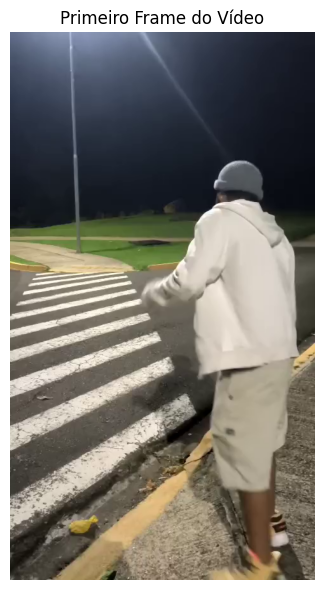

In [57]:
# Configurações do vídeo
video_path = "gym_videos"  # Pasta onde os vídeos são salvos

# Listar vídeos disponíveis
video_files = list(Path(video_path).glob("*.mp4"))

if video_files:
    print(f"Vídeos disponíveis na pasta '{video_path}':")
    for i, file in enumerate(video_files, 1):
        print(f"  {i}. {file.name}")
    
    # Usar o primeiro vídeo disponível
    selected_video = str(video_files[2])
    print(f"\nUsando: {selected_video}")
else:
    print(f"Nenhum vídeo encontrado em '{video_path}'")
    print("Use o script download_gym_video.py para baixar um vídeo primeiro!")
    selected_video = None

# Se houver vídeo, carregar suas informações
if selected_video and os.path.exists(selected_video):
    cap = cv2.VideoCapture(selected_video)
    
    # Obter propriedades do vídeo
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = frame_count / fps if fps > 0 else 0
    
    print(f"\n📹 Informações do Vídeo:")
    print(f"  Dimensões: {width}x{height}")
    print(f"  FPS: {fps:.2f}")
    print(f"  Total de Frames: {frame_count}")
    print(f"  Duração: {duration:.2f} segundos ({int(duration//60)}m{int(duration%60)}s)")
    
    # Ler e exibir o primeiro frame
    ret, frame = cap.read()
    if ret:
        print("\n✓ Primeiro frame carregado!")
        # Redimensionar para exibição
        display_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 6))
        plt.imshow(display_frame)
        plt.title("Primeiro Frame do Vídeo")
        plt.axis("off")
        plt.tight_layout()
        plt.show()
    
    cap.release()

## Section 3: Initialize MediaPipe Pose Detector

Initialize the MediaPipe Pose detector with appropriate configuration parameters for detecting human pose landmarks.

In [58]:
# Setup do MediaPipe Pose Landmarker
model_path = 'models/pose_landmarker_lite.task'

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

# Criar opções do PoseLandmarker
options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=VisionRunningMode.VIDEO,
    min_pose_detection_confidence=0.2,
    min_pose_presence_confidence=0.2,
)

# Criar instância do PoseLandmarker
landmarker = PoseLandmarker.create_from_options(options)

print("✓ MediaPipe Pose Landmarker inicializado com sucesso!")
print(f"  Modelo: {model_path}")
print(f"  Modo: Video")

✓ MediaPipe Pose Landmarker inicializado com sucesso!
  Modelo: models/pose_landmarker_lite.task
  Modo: Video


## Section 4: Process Video Frames

Iterate through video frames and use MediaPipe to detect pose landmarks for each frame, extracting coordinates and confidence scores.

In [59]:
# Processar vídeo e detectar poses
if selected_video and os.path.exists(selected_video):
    cap = cv2.VideoCapture(selected_video)
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Para não processar o vídeo inteiro (muito lento), pegar a cada 5 frames
    frame_skip = 5  # Processar a cada 5 frames (pode ser ajustado para 5 ou mais para acelerar)
    
    # Limitar a 2 minutos (1200 segundos)
    duration_limit_seconds = 1200
    max_frames = int(fps * duration_limit_seconds)
    frames_to_process = min(frame_count // frame_skip, max_frames // frame_skip)
    
    print(f"Processando {frames_to_process} frames (cada {frame_skip} frame)...")
    print(f"Limite: {duration_limit_seconds}s (primeiros 2 minutos)")
    
    processed_frames = []
    landmarks_data = []
    frame_count_actual = 0
    
    while cap.isOpened() and frame_count_actual < frames_to_process:
        ret, frame = cap.read()
        
        if not ret:
            break
        
        # Pular frames
        for _ in range(frame_skip - 1):
            cap.read()
        
        # Converter frame para MediaPipe Image
        image = mp.Image(image_format=mp.ImageFormat.SRGB, 
                        data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        
        # Executar pose detection
        pose_landmarker_result = landmarker.detect_for_video(image, frame_count_actual)
        
        # Armazenar frame e dados
        processed_frames.append(frame)
        landmarks_data.append(pose_landmarker_result)
        
        frame_count_actual += 1
        
        if frame_count_actual % 500 == 0:
            print(f"  Processados {frame_count_actual} frames...")
    
    cap.release()
    print(f"✓ Processamento completo! {len(processed_frames)} frames processados.")

Processando 207 frames (cada 5 frame)...
Limite: 1200s (primeiros 2 minutos)
✓ Processamento completo! 207 frames processados.


In [60]:
landmarks_data

[PoseLandmarkerResult(pose_landmarks=[[NormalizedLandmark(x=0.7148495316505432, y=0.30308443307876587, z=0.43765494227409363, visibility=0.9973406195640564, presence=0.9993575215339661, name=None), NormalizedLandmark(x=0.7196404337882996, y=0.28954949975013733, z=0.35378390550613403, visibility=0.9984064698219299, presence=0.9995139837265015, name=None), NormalizedLandmark(x=0.7171979546546936, y=0.2887776494026184, z=0.3535119891166687, visibility=0.9983678460121155, presence=0.9995424747467041, name=None), NormalizedLandmark(x=0.7143883109092712, y=0.2881450355052948, z=0.3533155024051666, visibility=0.9984276294708252, presence=0.9995697140693665, name=None), NormalizedLandmark(x=0.7317315340042114, y=0.28945228457450867, z=0.42252853512763977, visibility=0.9981312155723572, presence=0.9994472861289978, name=None), NormalizedLandmark(x=0.7368060946464539, y=0.28868186473846436, z=0.4221479594707489, visibility=0.9979897737503052, presence=0.9994634985923767, name=None), NormalizedLa

## Section 5: Draw Landmarks on Frames

Draw the detected pose landmarks and skeleton connections on each video frame using OpenCV drawing functions.

Desenhando landmarks de todas as pessoas nos frames...
✓ Landmarks desenhados em 207 frames!


(np.float64(-0.5), np.float64(479.5), np.float64(863.5), np.float64(-0.5))

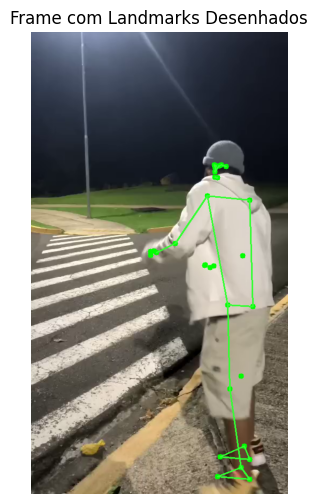

In [ ]:
# Função para desenhar landmarks nos frames
def draw_landmarks_on_frame(frame, pose_result):
    """Desenha os landmarks de todas as pessoas detectadas no frame"""
    h, w, c = frame.shape
    frame_copy = frame.copy()
    
    if pose_result.pose_landmarks:
        # Iterar sobre todas as pessoas detectadas
        for person_idx, landmarks in enumerate(pose_result.pose_landmarks):
            # Cores diferentes para cada pessoa
            colors = [
                (0, 255, 0),      # Verde
                (255, 0, 0),      # Azul
                (0, 0, 255),      # Vermelho
                (255, 255, 0),    # Ciano
                (255, 0, 255),    # Magenta
                (0, 255, 255),    # Amarelo
            ]
            circle_color = colors[person_idx % len(colors)]
            line_color = tuple(min(255, c + 50) for c in circle_color)  # Versão mais clara
            
            # Desenhar círculos nos landmarks
            for landmark in landmarks:
                x = int(landmark.x * w)
                y = int(landmark.y * h)
                cv2.circle(frame_copy, (x, y), 5, circle_color, -1)
            
            # Definir conexões entre pontos (skeleton)
            # Conexões baseadas no COCO formato
            connections = [
                (0, 1), (0, 4), (1, 2), (2, 3), (3, 7), (4, 5), (5, 6), (6, 8),
                (9, 10), (11, 12), (11, 13), (13, 15), (12, 14), (14, 16),
                (11, 23), (12, 24), (23, 24), (23, 25), (24, 26), (25, 27),
                (26, 28), (27, 29), (28, 30), (29, 31), (30, 32), (27, 31), (28, 32)
            ]
            
            # Desenhar conexões
            for start, end in connections:
                if start < len(landmarks) and end < len(landmarks):
                    start_point = landmarks[start]
                    end_point = landmarks[end]
                    
                    start_x = int(start_point.x * w)
                    start_y = int(start_point.y * h)
                    end_x = int(end_point.x * w)
                    end_y = int(end_point.y * h)
                    
                    # Desenhar apenas se ambos os pontos têm boa confiança
                    if start_point.visibility > 0.3 and end_point.visibility > 0.3:
                        cv2.line(frame_copy, (start_x, start_y), (end_x, end_y), line_color, 2)
    
    return frame_copy

# Desenhar landmarks em todos os frames processados
print("Desenhando landmarks de todas as pessoas nos frames...")
frames_with_landmarks = []
for i, (frame, landmark_result) in enumerate(zip(processed_frames, landmarks_data)):
    frame_with_landmarks = draw_landmarks_on_frame(frame, landmark_result)
    frames_with_landmarks.append(frame_with_landmarks)
    if (i + 1) % 500 == 0:
        print(f"  {i + 1} frames desenhados...")

print(f"✓ Landmarks desenhados em {len(frames_with_landmarks)} frames!")

## Section 6: Display Results

Display processed frames with landmarks and create visualizations showing the pose detection results.

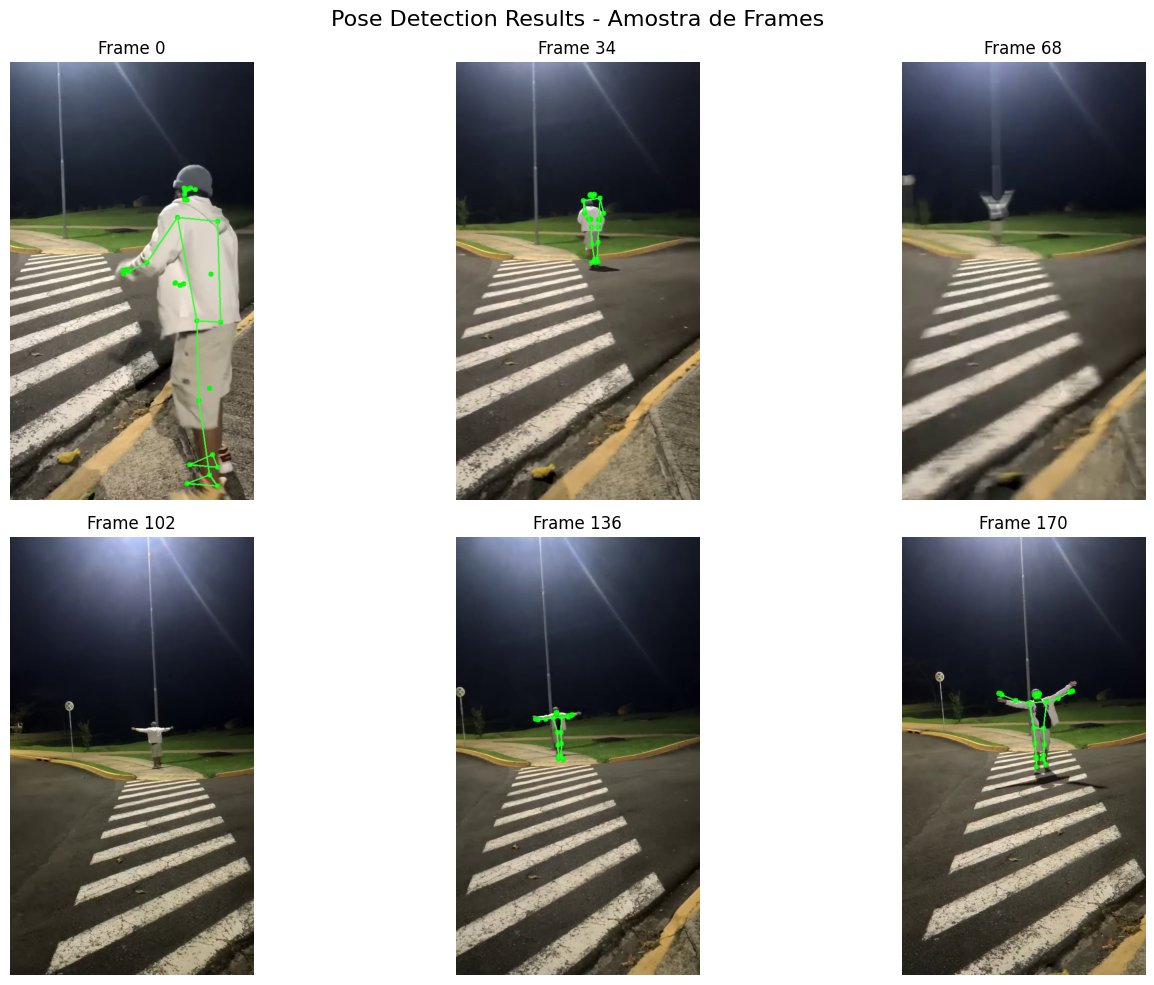

✓ Visualização completa!

Salvando vídeo processado...
✓ Vídeo salvo em: output_pose_detection.mp4
  Resolução: 480x864
  Frames: 207
  FPS: 6.00

✓ Análise concluída com sucesso!


In [63]:
# Exibir um exemplo dos resultados
if frames_with_landmarks:
    # Mostrar múltiplos frames em uma grid
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Pose Detection Results - Amostra de Frames', fontsize=16)
    
    num_frames_to_show = min(6, len(frames_with_landmarks))
    step = len(frames_with_landmarks) // num_frames_to_show if num_frames_to_show > 0 else 1
    
    for idx, ax in enumerate(axes.flat):
        if idx < num_frames_to_show:
            frame_idx = idx * step
            frame = frames_with_landmarks[frame_idx]
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            ax.imshow(frame_rgb)
            ax.set_title(f'Frame {frame_idx}')
            ax.axis('off')
        else:
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Visualização completa!")

# Salvar vídeo processado
print("\nSalvando vídeo processado...")
output_video_path = "output_pose_detection.mp4"

if frames_with_landmarks:
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, fps/frame_skip, 
                         (frame_width, frame_height))  # fps/5 pois pulamos frames
    
    for frame in frames_with_landmarks:
        out.write(frame)
    
    out.release()
    print(f"✓ Vídeo salvo em: {output_video_path}")
    print(f"  Resolução: {frame_width}x{frame_height}")
    print(f"  Frames: {len(frames_with_landmarks)}")
    print(f"  FPS: {fps/5:.2f}")

# Fechar o landmarker
landmarker.close()
print("\n✓ Análise concluída com sucesso!")